# Neural responses to natural images versus artificial gratings in the mouse visual cortex

**Group members:** Saaim Farhan, Bassam Hajjawi, Dhruv Sood

**Course:** COGS 138 — Final Project

## I. Experimental question

Do neurons in the mouse primary visual cortex (V1 / VISp) respond more strongly to natural images than to artificial drifting gratings?

## II. Background

The primary visual cortex is the first cortical area responsible for processing visual information. Classical experiments using artificial stimuli have characterized properties such as orientation selectivity and spatial frequency tuning, but these stimuli only capture a narrow slice of the visual world. Real-world scenes contain rich textures, structure, and statistical regularities that may drive V1 circuits very differently from controlled lab stimuli. de Vries et al. (2020) showed that the visual system is adapted to process the structure of natural environments efficiently, suggesting that natural scenes are crucial to the functional organization of V1.

Recent work has revealed aspects of V1 function that artificial drifting gratings miss. Yoshida and Ohki (2020) demonstrated that small populations of neurons can reliably encode natural images, and Froudarakis et al. (2019) found that natural scenes elicit broader feature selectivity than standard gratings. Using the Allen Brain Observatory dataset, we compare V1 responses to natural images and drifting gratings to test whether realistic stimuli evoke stronger, more reliable, or more sparse responses than artificial ones.

**Primary sources**
- Yoshida, T., & Ohki, K. (2020). *Natural images are reliably represented by sparse and variable populations of neurons in visual cortex.* Nature Communications, 11(1), 872.
- Froudarakis, E. et al. (2019). *Population code in mouse V1 facilitates readout of natural scenes through increased sparseness.* Nature Neuroscience, 22, 1418–1428.
- de Vries, S. E. J. et al. (2020). *A large-scale standardized physiological survey reveals functional organization of the mouse visual cortex.* Nature Neuroscience, 23(1), 138–151.

## III. Approach

**Dataset.** Allen Brain Observatory Visual Coding dataset, accessed via the `AllenSDK` Python package. We focus on primary visual cortex (VISp) recordings that include both natural scenes and drifting gratings stimulus blocks.

**Pipeline.**
1. Install AllenSDK and initialize `BrainObservatoryCache`.
2. Select VISp experiment containers that have both a drifting-grating session and a natural-scene session.
3. For each container, load ΔF/F fluorescence traces and match cells across sessions using `cell_specimen_id`.
4. Extract stimulus presentation timestamps for natural images and drifting gratings.
5. For each presentation, take the mean ΔF/F in the first 500 ms after stimulus onset (baseline-subtracted).
6. For each neuron, compute:
   - **Mean response magnitude** — how strongly the neuron responds.
   - **Response reliability** — consistency across repeated presentations.
   - **Lifetime sparseness** — whether the neuron responds to many stimuli or only a few.
7. Compare distributions across stimulus types with bar plots, scatter plots, and paired t-tests.

## 1. Setup

Install AllenSDK (Colab) and import the libraries we need. The first cell only needs to run once per environment.

In [4]:
try:
    import allensdk
    print('allensdk imported')
except ImportError as e:
    !pip install allensdk

allensdk imported


In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from allensdk.core.brain_observatory_cache import BrainObservatoryCache
import allensdk.brain_observatory.stimulus_info as stim_info

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

## 2. Initialize the cache and select VISp experiments

The Allen Brain Observatory splits each experiment container into three imaging sessions (A, B, C). Drifting gratings live in session A and natural scenes live in session B, so we collect both for the same set of containers.

In [6]:
MANIFEST_PATH = os.path.join('boc', 'manifest.json')
boc = BrainObservatoryCache(manifest_file=MANIFEST_PATH)

visp_containers = boc.get_experiment_containers(targeted_structures=['VISp'])
container_ids = [c['id'] for c in visp_containers]
print(f'Found {len(container_ids)} VISp experiment containers')

dg_exps = boc.get_ophys_experiments(
    experiment_container_ids=container_ids,
    stimuli=[stim_info.DRIFTING_GRATINGS],
)
ns_exps = boc.get_ophys_experiments(
    experiment_container_ids=container_ids,
    stimuli=[stim_info.NATURAL_SCENES],
)

dg_by_container = {e['experiment_container_id']: e['id'] for e in dg_exps}
ns_by_container = {e['experiment_container_id']: e['id'] for e in ns_exps}

paired_containers = sorted(set(dg_by_container) & set(ns_by_container))
print(f'Containers with both DG and NS sessions: {len(paired_containers)}')

Found 216 VISp experiment containers
Containers with both DG and NS sessions: 144


We pick a small subset of containers to keep download/compute time tractable. Increase `N_CONTAINERS` to scale up.

In [7]:
N_CONTAINERS = 5
selected_containers = paired_containers[:N_CONTAINERS]
selected_containers

[511498742, 511507650, 511507811, 511509529, 511510650]

## 3. Helper functions: response window, reliability, sparseness

For each stimulus presentation we take the mean ΔF/F in the first 500 ms after onset and subtract a 500 ms pre-stimulus baseline. From the resulting trial × stimulus response matrix we compute per-neuron summary statistics.

In [8]:
RESPONSE_WINDOW_S = 0.5  # post-stimulus window
BASELINE_WINDOW_S = 0.5  # pre-stimulus window

def frames_per_window(timestamps, seconds):
    """Convert a time window in seconds to a frame count for this recording."""
    dt = np.median(np.diff(timestamps))
    return max(int(round(seconds / dt)), 1)

def trial_responses(dff, timestamps, stim_table, stim_id_col):
    """Return an array of shape (n_cells, n_trials) with baseline-subtracted responses,
    plus the stimulus id for each trial."""
    win = frames_per_window(timestamps, RESPONSE_WINDOW_S)
    base = frames_per_window(timestamps, BASELINE_WINDOW_S)
    n_cells = dff.shape[0]
    n_trials = len(stim_table)
    responses = np.full((n_cells, n_trials), np.nan)
    stim_ids = np.full(n_trials, -1)
    for i, row in enumerate(stim_table.itertuples(index=False)):
        start = int(row.start)
        if start - base < 0 or start + win > dff.shape[1]:
            continue
        post = dff[:, start:start + win].mean(axis=1)
        pre = dff[:, start - base:start].mean(axis=1)
        responses[:, i] = post - pre
        stim_ids[i] = getattr(row, stim_id_col)
    keep = stim_ids >= 0
    return responses[:, keep], stim_ids[keep]

def mean_response_per_stim(responses, stim_ids):
    """Average trial responses for each unique stimulus -> (n_cells, n_stim)."""
    unique = np.unique(stim_ids)
    out = np.zeros((responses.shape[0], len(unique)))
    for j, s in enumerate(unique):
        out[:, j] = np.nanmean(responses[:, stim_ids == s], axis=1)
    return out

def reliability(responses, stim_ids):
    """Trial-to-trial reliability: mean Pearson correlation between split halves of trials,
    computed per neuron across stimuli. Returns a vector of length n_cells."""
    n_cells = responses.shape[0]
    rels = np.full(n_cells, np.nan)
    unique = np.unique(stim_ids)
    if len(unique) < 2:
        return rels
    n_repeats = min((stim_ids == s).sum() for s in unique)
    if n_repeats < 2:
        return rels
    half = n_repeats // 2
    if half < 1:
        return rels
    a = np.zeros((n_cells, len(unique)))
    b = np.zeros((n_cells, len(unique)))
    for j, s in enumerate(unique):
        idx = np.where(stim_ids == s)[0]
        np.random.shuffle(idx)
        a[:, j] = np.nanmean(responses[:, idx[:half]], axis=1)
        b[:, j] = np.nanmean(responses[:, idx[half:2 * half]], axis=1)
    for c in range(n_cells):
        if np.all(np.isfinite(a[c])) and np.all(np.isfinite(b[c])):
            if np.std(a[c]) > 0 and np.std(b[c]) > 0:
                rels[c] = np.corrcoef(a[c], b[c])[0, 1]
    return rels

def lifetime_sparseness(mean_per_stim):
    """Treves-Rolls lifetime sparseness, one value per neuron.
    1 = responds to a single stimulus, 0 = responds equally to all."""
    r = np.clip(mean_per_stim, 0, None)  # rectify
    n = r.shape[1]
    num = (r.sum(axis=1) ** 2) / n
    den = (r ** 2).sum(axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        s = 1 - (num / den)
        s = s / (1 - 1 / n)
    return s

## 4. Load each container, compute per-neuron metrics for both stimulus types

We only keep neurons whose `cell_specimen_id` appears in *both* sessions, so every comparison below is paired within neuron.

In [9]:
records = []

for cid in selected_containers:
    print(f'\n=== container {cid} ===')
    try:
        dg_data = boc.get_ophys_experiment_data(ophys_experiment_id=dg_by_container[cid])
        ns_data = boc.get_ophys_experiment_data(ophys_experiment_id=ns_by_container[cid])
    except Exception as e:
        print(f'  skipped: {e}')
        continue

    dg_ts, dg_dff = dg_data.get_dff_traces()
    ns_ts, ns_dff = ns_data.get_dff_traces()

    dg_cells = np.array(dg_data.get_cell_specimen_ids())
    ns_cells = np.array(ns_data.get_cell_specimen_ids())
    shared = np.intersect1d(dg_cells, ns_cells)
    if len(shared) == 0:
        print('  no shared cells, skipping')
        continue
    dg_idx = np.array([np.where(dg_cells == c)[0][0] for c in shared])
    ns_idx = np.array([np.where(ns_cells == c)[0][0] for c in shared])
    dg_dff = dg_dff[dg_idx]
    ns_dff = ns_dff[ns_idx]
    print(f'  shared cells: {len(shared)}')

    dg_table = dg_data.get_stimulus_table('drifting_gratings')
    dg_table = dg_table.dropna(subset=['orientation', 'temporal_frequency']).copy()
    # treat each (orientation, temporal_frequency) combo as a unique stimulus
    dg_table['stim_id'] = (
        dg_table['orientation'].astype(int).astype(str) + '_' + dg_table['temporal_frequency'].astype(str)
    )
    dg_table['stim_id'] = pd.Categorical(dg_table['stim_id']).codes

    ns_table = ns_data.get_stimulus_table('natural_scenes')
    ns_table = ns_table[ns_table['frame'] >= 0].copy()  # drop blank sweeps
    ns_table['stim_id'] = ns_table['frame'].astype(int)

    dg_resp, dg_stim = trial_responses(dg_dff, dg_ts, dg_table, 'stim_id')
    ns_resp, ns_stim = trial_responses(ns_dff, ns_ts, ns_table, 'stim_id')
    if dg_resp.size == 0 or ns_resp.size == 0:
        print('  no usable trials, skipping')
        continue

    dg_mean_stim = mean_response_per_stim(dg_resp, dg_stim)
    ns_mean_stim = mean_response_per_stim(ns_resp, ns_stim)

    df = pd.DataFrame({
        'container_id': cid,
        'cell_specimen_id': shared,
        'dg_mean': np.nanmean(dg_resp, axis=1),
        'ns_mean': np.nanmean(ns_resp, axis=1),
        'dg_reliability': reliability(dg_resp, dg_stim),
        'ns_reliability': reliability(ns_resp, ns_stim),
        'dg_sparseness': lifetime_sparseness(dg_mean_stim),
        'ns_sparseness': lifetime_sparseness(ns_mean_stim),
    })
    records.append(df)

metrics = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
print(f'\nTotal neurons in analysis: {len(metrics)}')
metrics.head()

2026-05-31 23:15:51,985 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/516362573



=== container 511498742 ===


2026-05-31 23:17:57,550 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/516251318


  shared cells: 131


2026-05-31 23:18:53,434 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/514612445


...

2026-05-31 23:29:01,780 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/514393873



=== container 511510650 ===


2026-05-31 23:29:46,067 allensdk.api.api.retrieve_file_over_http INFO     Downloading URL: http://api.brain-map.org/api/v2/well_known_file_download/514376818


  shared cells: 114

Total neurons in analysis: 592


,container_id,cell_specimen_id,dg_mean,ns_mean,dg_reliability,ns_reliability,dg_sparseness,ns_sparseness
0,511498742,517397365,-0.002413,-0.000048,0.020650,0.534000,0.852867,0.893369
1,511498742,517397369,-0.002606,0.000070,0.097874,0.230306,0.866187,0.777501
2,511498742,517397373,-0.003207,0.000027,0.169664,0.098455,0.778110,0.784185
3,511498742,517397377,-0.002003,0.000058,0.330139,0.492836,0.803208,0.730987
4,511498742,517397381,-0.003032,0.000367,0.138558,0.513161,0.919415,0.829376


## 5. Compare distributions

Drop any neurons where a metric could not be computed (e.g., zero variance) so the paired comparisons line up.

In [10]:
clean = metrics.dropna(subset=[
    'dg_mean', 'ns_mean',
    'dg_reliability', 'ns_reliability',
    'dg_sparseness', 'ns_sparseness',
]).reset_index(drop=True)
print(f'Neurons with complete metrics: {len(clean)}')
clean.describe()

Neurons with complete metrics: 588


,container_id,cell_specimen_id,dg_mean,ns_mean,dg_reliability,ns_reliability,dg_sparseness,ns_sparseness
count,5.880000e+02,5.880000e+02,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000
mean,5.115068e+08,5.278822e+08,-0.000140,0.000095,0.158213,0.439157,0.745956,0.833561
std,4.430225e+03,2.499006e+07,0.012289,0.000240,0.230331,0.198290,0.142471,0.066166
min,5.114987e+08,5.173974e+08,-0.091862,-0.001210,-0.389129,-0.147113,0.320339,0.657021
25%,5.115076e+08,5.174063e+08,-0.003322,0.000025,0.011082,0.293971,0.658041,0.784412
50%,5.115078e+08,5.174092e+08,-0.000098,0.000078,0.131915,0.443344,0.766604,0.830207
75%,5.115095e+08,5.174199e+08,0.003029,0.000147,0.270179,0.575344,0.861080,0.883907
max,5.115106e+08,5.891537e+08,0.119965,0.001901,0.958212,0.867254,1.000000,0.980137


### 5a. Mean response magnitude

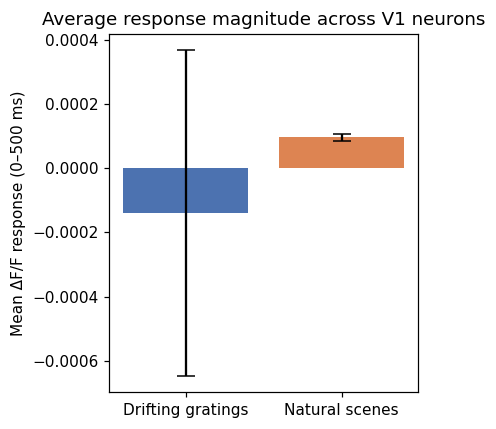

In [11]:
means = [clean['dg_mean'].mean(), clean['ns_mean'].mean()]
sems = [stats.sem(clean['dg_mean']), stats.sem(clean['ns_mean'])]
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Drifting gratings', 'Natural scenes'], means, yerr=sems, capsize=6,
       color=['#4c72b0', '#dd8452'])
ax.set_ylabel('Mean ΔF/F response (0–500 ms)')
ax.set_title('Average response magnitude across V1 neurons')
plt.tight_layout()
plt.show()

### 5b. Response reliability — paired scatter

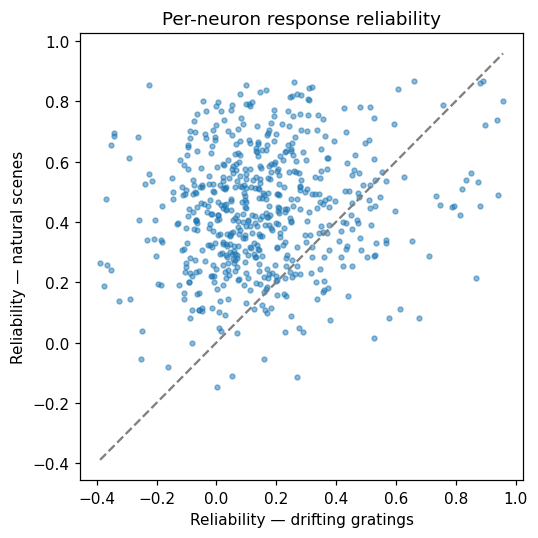

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(clean['dg_reliability'], clean['ns_reliability'], s=10, alpha=0.5)
lim = [min(clean['dg_reliability'].min(), clean['ns_reliability'].min()),
       max(clean['dg_reliability'].max(), clean['ns_reliability'].max())]
ax.plot(lim, lim, '--', color='gray')
ax.set_xlabel('Reliability — drifting gratings')
ax.set_ylabel('Reliability — natural scenes')
ax.set_title('Per-neuron response reliability')
plt.tight_layout()
plt.show()

### 5c. Lifetime sparseness

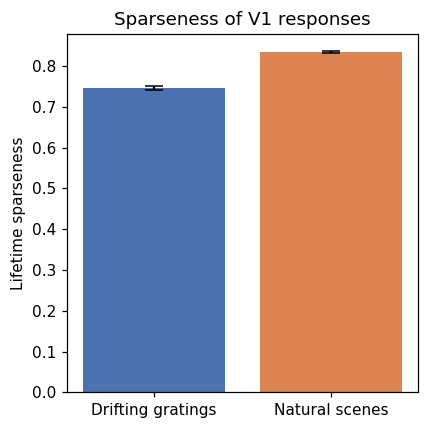

In [13]:
means = [clean['dg_sparseness'].mean(), clean['ns_sparseness'].mean()]
sems = [stats.sem(clean['dg_sparseness']), stats.sem(clean['ns_sparseness'])]
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(['Drifting gratings', 'Natural scenes'], means, yerr=sems, capsize=6,
       color=['#4c72b0', '#dd8452'])
ax.set_ylabel('Lifetime sparseness')
ax.set_title('Sparseness of V1 responses')
plt.tight_layout()
plt.show()

## 6. Statistical tests

Each neuron contributes a paired (drifting-grating, natural-scene) measurement, so we use paired t-tests for the three metrics.

In [14]:
def paired(metric):
    a = clean[f'dg_{metric}']
    b = clean[f'ns_{metric}']
    t, p = stats.ttest_rel(a, b)
    return {'metric': metric, 'dg_mean': a.mean(), 'ns_mean': b.mean(),
            't': t, 'p': p, 'n': len(a)}

results = pd.DataFrame([paired('mean'), paired('reliability'), paired('sparseness')])
results

,metric,dg_mean,ns_mean,t,p,n
0,mean,-0.000140,0.000095,-0.465534,6.417220e-01,588
1,reliability,0.158213,0.439157,-24.376056,3.428568e-91,588
2,sparseness,0.745956,0.833561,-12.989802,4.308432e-34,588


## 7. Discussion

Interpret the results in light of the original question:
- A larger mean ΔF/F for natural scenes would indicate stronger drive from naturalistic input.
- Higher reliability for natural scenes would suggest more reproducible neural codes for real-world structure.
- Higher lifetime sparseness for natural scenes would replicate the increased sparseness reported by Froudarakis et al. (2019).

Caveats: only `N_CONTAINERS` containers were analyzed, so the effect sizes here are a first pass rather than a population-level estimate. Cre line, imaging depth, and cortical layer differ across containers and are not controlled for. The 500 ms response window also captures only the early evoked response and ignores later/sustained dynamics that may differ between stimulus types.